In [1]:
#Install & Import Libraries
!pip install ucimlrepo -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from ucimlrepo import fetch_ucirepo #fetch dataset directly
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

print("All libraries loaded successfully")

All libraries loaded successfully


In [2]:
# Load Dataset from UCI
# Fetch Air Quality dataset (id=360)
air_quality = fetch_ucirepo(id=360)

X = air_quality.data.features  #input independent variables like temp humidity
y = air_quality.data.targets   #output dependent variables

df = pd.concat([X, y], axis=1)
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


In [3]:
# Data Cleaning & Preprocessing
# Re-create df from original X and y to ensure 'Date' and 'Time' columns are present
df = pd.concat([X, y], axis=1)

# Replacing  missing value sentinel (-200) with NaN because model doesnt know -200
df.replace(-200, np.nan, inplace=True)

# create datetime from Date and Time columns
df['Datetime'] = pd.to_datetime(
    df['Date'].astype(str) + ' ' + df['Time'].astype(str), #checks if both are string
    format='%m/%d/%Y %H:%M:%S',
    errors='coerce'
)
df.set_index('Datetime', inplace=True) #because time series model needs datetime index
df.drop(columns=['Date', 'Time'], inplace=True)

# Drop fully empty rows
df.dropna(how='all', inplace=True)

df.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
Datetime,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
2004-03-10 19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2004-03-10 20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
2004-03-10 21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
2004-03-10 22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [4]:
#  Missing Value Analysis
df.fillna(method='ffill', inplace=True) #if empty values fills with the previous value

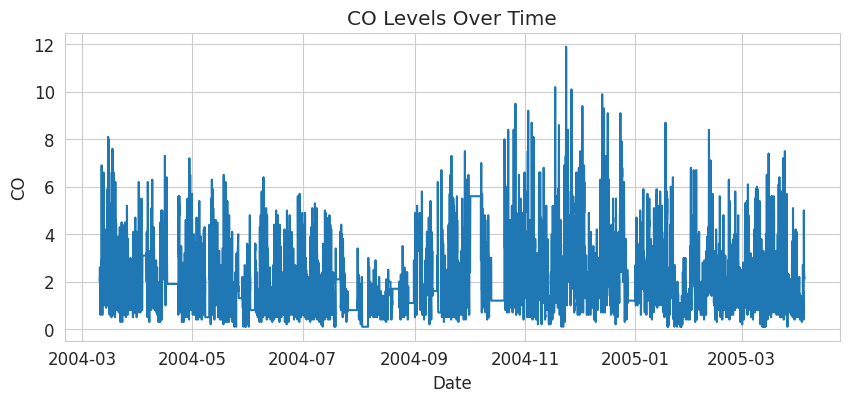

In [5]:
# Time-Series Plots for Key Pollutants
series = df['CO(GT)']

plt.figure(figsize=(10,4))
plt.plot(series)
plt.title("CO Levels Over Time")
plt.xlabel("Date")
plt.ylabel("CO")
plt.show()

#plots the basic graph

In [6]:
# ADF stationary test
from statsmodels.tsa.stattools import adfuller

series = df['CO(GT)'].dropna() #removes empty values

result = adfuller(series) #applying adf test

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Series is stationary")
else:
    print("Series is not stationary")

ADF Statistic: -9.383269776097505
p-value: 6.865867849987463e-16
Series is stationary


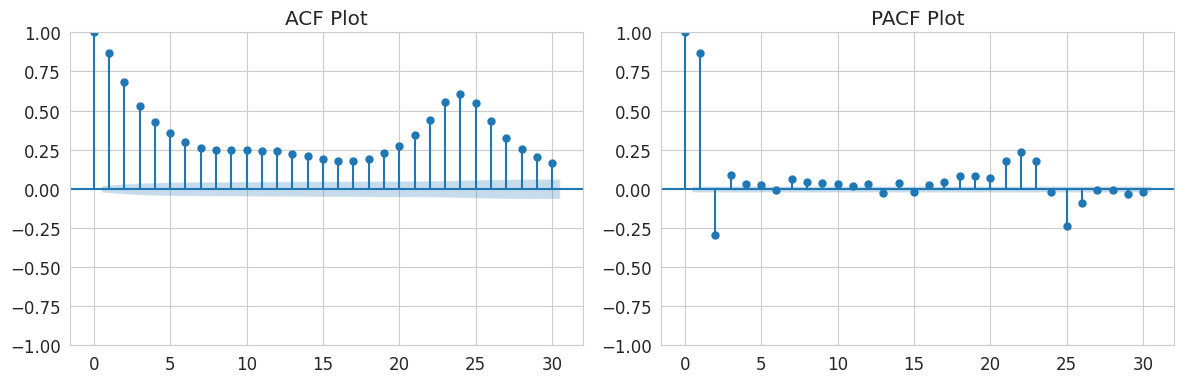

In [7]:
# ACF PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Select target column
series = df['CO(GT)'].dropna()

# Plot ACF and PACF
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ACF: helps find q
plot_acf(series, lags=30, ax=axes[0])
axes[0].set_title("ACF Plot")

# PACF: helps find p
plot_pacf(series, lags=30, ax=axes[1])
axes[1].set_title("PACF Plot")

plt.tight_layout()
plt.show()

In [8]:
# EDA Summary

print("EDA Summary")

print("\nDataset loaded and cleaned")
print("Replaced -200 with NaN")
print("Created datetime index")
print("Handled missing values using forward fill")

print("\nTime-series analysis")
print("Selected CO(GT) as target variable")
print("Visualized trend using time-series plot")

print("\nModel preparation")
print("Checked stationarity using ADF test")
print("Used ACF and PACF for parameter selection")

print("\nNext Step:")
print("Train ARIMA model and generate forecast")

EDA Summary

Dataset loaded and cleaned
Replaced -200 with NaN
Created datetime index
Handled missing values using forward fill

Time-series analysis
Selected CO(GT) as target variable
Visualized trend using time-series plot

Model preparation
Checked stationarity using ADF test
Used ACF and PACF for parameter selection

Next Step:
Train ARIMA model and generate forecast


In [9]:
# arima approach
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(series, order=(1,1,1)) #defines arima 1,1,1 represents p,d,q

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

# Select target variable
series = df['CO(GT)'].dropna()

# Train-test split (80/20)
split_idx = int(len(series) * 0.8) #Calculates 80% of data length
train = series[:split_idx] #first 80% trains the model
test = series[split_idx:] #last 20% evaluates the model

print("Train size:", len(train))
print("Test size:", len(test))



Train size: 7460
Test size: 1866


In [11]:
# Train ARIMA model
model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

# Forecast
forecast = model_fit.forecast(steps=len(test)) #predicting the next len(test) values using the trained model

# Evaluation
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1.1384604625446342
RMSE: 1.405458572007365


In [12]:
# Thresholds
CO_THRESHOLD_MODERATE = 2.0
CO_THRESHOLD_HIGH = 4.0
CO_THRESHOLD_CRITICAL = 8.0

def classify_alert(value):
    if value >= CO_THRESHOLD_CRITICAL:
        return 'CRITICAL'
    elif value >= CO_THRESHOLD_HIGH:
        return 'HIGH'
    elif value >= CO_THRESHOLD_MODERATE:
        return 'MODERATE'
    else:
        return 'NORMAL'

forecast_df = pd.DataFrame({
    'Actual': test.values,
    'Forecast': forecast.values
})

forecast_df['Alert'] = forecast_df['Forecast'].apply(classify_alert)

print(forecast_df.head())

   Actual  Forecast     Alert
0     1.5  2.176400  MODERATE
1     1.2  2.180671  MODERATE
2     1.5  2.179898  MODERATE
3     1.4  2.180038  MODERATE
4     1.2  2.180012  MODERATE


In [13]:
# Ensure metrics are computed correctly before summary
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))


print(" AIR QUALITY EARLY WARNING SYSTEM — SUMMARY")


print("\nDATA PREPARATION")
print("Loaded and cleaned dataset")
print("Replaced missing values and created time index")

print("\nEDA & ANALYSIS")
print("Selected CO(GT) as target variable")
print("Visualized time-series trends")
print("Checked stationarity using ADF test")
print("Used ACF and PACF for parameter selection")

print("\nMODEL")
print("Applied ARIMA(1,1,1) model")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")

print("\nALERT SYSTEM")
print(f"Normal   : CO < {CO_THRESHOLD_MODERATE}")
print(f"Moderate : CO >= {CO_THRESHOLD_MODERATE}")
print(f"High     : CO >= {CO_THRESHOLD_HIGH}")
print(f"Critical : CO >= {CO_THRESHOLD_CRITICAL}")

print("\nCONCLUSION")
print("Model can forecast pollution levels")
print("Alerts help in early warning system")



 AIR QUALITY EARLY WARNING SYSTEM — SUMMARY

DATA PREPARATION
Loaded and cleaned dataset
Replaced missing values and created time index

EDA & ANALYSIS
Selected CO(GT) as target variable
Visualized time-series trends
Checked stationarity using ADF test
Used ACF and PACF for parameter selection

MODEL
Applied ARIMA(1,1,1) model
MAE  : 1.1385
RMSE : 1.4055

ALERT SYSTEM
Normal   : CO < 2.0
Moderate : CO >= 2.0
High     : CO >= 4.0
Critical : CO >= 8.0

CONCLUSION
Model can forecast pollution levels
Alerts help in early warning system
